In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate

df = pd.read_csv('AmesHousing.csv')
df = df.drop(columns=df.select_dtypes(include=object))
df = df.dropna()

X = df.drop(columns='SalePrice')
Y = df['SalePrice']

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2274 entries, 0 to 2929
Data columns (total 39 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2274 non-null   int64  
 1   PID              2274 non-null   int64  
 2   MS SubClass      2274 non-null   int64  
 3   Lot Frontage     2274 non-null   float64
 4   Lot Area         2274 non-null   int64  
 5   Overall Qual     2274 non-null   int64  
 6   Overall Cond     2274 non-null   int64  
 7   Year Built       2274 non-null   int64  
 8   Year Remod/Add   2274 non-null   int64  
 9   Mas Vnr Area     2274 non-null   float64
 10  BsmtFin SF 1     2274 non-null   float64
 11  BsmtFin SF 2     2274 non-null   float64
 12  Bsmt Unf SF      2274 non-null   float64
 13  Total Bsmt SF    2274 non-null   float64
 14  1st Flr SF       2274 non-null   int64  
 15  2nd Flr SF       2274 non-null   int64  
 16  Low Qual Fin SF  2274 non-null   int64  
 17  Gr Liv Area      22

Definindo $\lambda$ (Embora haja bibliotecas prontas para definir o parâmetro, resolvi definir manualmente a primeira vez por fins didáticos)

In [39]:
lamb = np.linspace(10,900,100)

erros = []

for i in range(len(lamb)):

    model = Pipeline([
        ('scaler',StandardScaler()),
        ('ridge',Ridge(alpha=lamb[i]))
    ])

    cv = KFold(n_splits=10,shuffle=True,random_state=0)

    mse = cross_validate(model,X,Y,cv=cv,scoring='neg_mean_squared_error')

    erros.append(-mse['test_score'].mean())

lamb_opm = lamb[np.argmin(erros)]

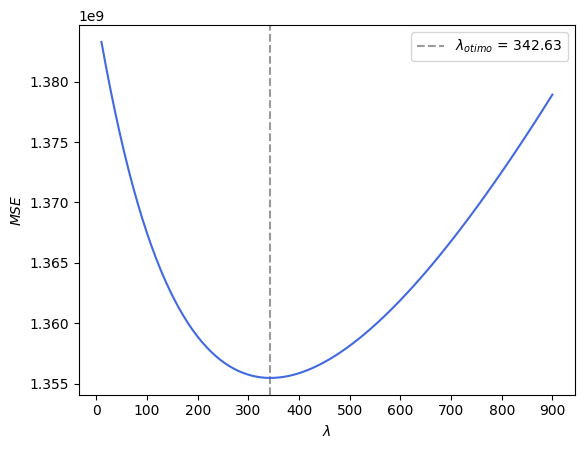

In [40]:
plt.figure()
plt.axvline(x=lamb_opm,ls='--',color='black',alpha=0.4, label = rf'$\lambda_{{otimo}}$ = {lamb_opm:.2f}')
plt.plot(lamb,erros,color='royalblue')
plt.ylabel(r'$MSE$')
plt.xlabel(r'$\lambda$')
plt.xticks(np.arange(0,910,100))
plt.legend()
plt.show()

In [41]:
model = Pipeline([
    ('norm',StandardScaler()),
    ('ridge',Ridge(alpha=lamb_opm))
])

cv = KFold(n_splits=10,shuffle=True,random_state=1)

results = cross_validate(model,X,Y,cv=cv,
                         scoring={'MSE':'neg_mean_squared_error',
                                  'RMSE':'neg_root_mean_squared_error',
                                  'MAE':'neg_mean_absolute_error',
                                  'R2':'r2'})

rmse = -results['test_RMSE']
r2 = results['test_R2']

print('Resultado via Ridge Regression:')
print(f'RMSE: {rmse.mean():.4f} ± {rmse.std():.4f}')
print(f'R²:   {r2.mean():.4f} ± {r2.std():.4f}')

### COMPARANDO COM LEAST SQUARES

model = Pipeline([
    #('norm',StandardScaler()),
    ('OLS',LinearRegression())
])

cv = KFold(n_splits=10,shuffle=True,random_state=1)

results = cross_validate(model,X,Y,cv=cv,
                         scoring={'MSE':'neg_mean_squared_error',
                                  'RMSE':'neg_root_mean_squared_error',
                                  'MAE':'neg_mean_absolute_error',
                                  'R2':'r2'})

rmse = -results['test_RMSE']
r2 = results['test_R2']

print('\nResultado via Linear Regression:')
print(f'RMSE: {rmse.mean():.4f} ± {rmse.std():.4f}')
print(f'R²:   {r2.mean():.4f} ± {r2.std():.4f}')

Resultado via Ridge Regression:
RMSE: 35235.0061 ± 11366.0530
R²:   0.8098 ± 0.1219

Resultado via Linear Regression:
RMSE: 35413.4876 ± 12365.8708
R²:   0.8054 ± 0.1380


In [42]:
ols = LinearRegression()
ridge = Ridge(alpha=lamb_opm)

ols.fit(X, Y)
ridge.fit(X, Y)

for feature, b_ols, b_ridge in zip(X.columns,
                                    ols.coef_,
                                    ridge.coef_):

    print(f'{feature:20s} '
          f'OLS = {b_ols:10.4f}   '
          f'Ridge = {b_ridge:10.4f}')

Order                OLS =   -17.4104   Ridge =    -2.3560
PID                  OLS =     0.0000   Ridge =    -0.0000
MS SubClass          OLS =  -185.0462   Ridge =  -197.7572
Lot Frontage         OLS =   -88.3415   Ridge =  -104.7174
Lot Area             OLS =     0.6338   Ridge =     0.6440
Overall Qual         OLS = 18078.4392   Ridge = 16013.5486
Overall Cond         OLS =  4190.1580   Ridge =  3603.9807
Year Built           OLS =   305.0382   Ridge =   335.1369
Year Remod/Add       OLS =   175.1357   Ridge =   279.9303
Mas Vnr Area         OLS =    34.8243   Ridge =    37.9506
BsmtFin SF 1         OLS =    13.0493   Ridge =    15.1464
BsmtFin SF 2         OLS =     3.0277   Ridge =     3.5382
Bsmt Unf SF          OLS =    -4.1262   Ridge =    -3.8490
Total Bsmt SF        OLS =    11.9507   Ridge =    14.8356
1st Flr SF           OLS =    20.3091   Ridge =    18.8450
2nd Flr SF           OLS =    18.6695   Ridge =    20.2341
Low Qual Fin SF      OLS =    -4.2146   Ridge =    -0.65

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=4.23967e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
